# 02 — EDA and PCA

Performs exploratory data analysis and applies PCA for dimensionality reduction and visualization.
Saves train/test splits, StandardScaler, and PCA objects via joblib.

## 2.1 Import Libraries


In [53]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import joblib

FIGURES_DIR = "figures"
DATA_DIR = "data"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2.2 Load Data

In [54]:
molecule_df = pd.read_csv(os.path.join(DATA_DIR, "molecules.csv"))
print(f"Data shape: {molecule_df.shape}")
print(f"Columns: {len(molecule_df.columns)} (3 metadata + {len(molecule_df.columns) - 3} features)")
print(f"\nClass distribution:")
print(molecule_df.groupby(["class_label", "class_name"]).size())
molecule_df.head()

Data shape: (36, 155)
Columns: 155 (3 metadata + 152 features)

Class distribution:
class_label  class_name        
0            Capsaicinoid          12
1            Vanilloid_Gingerol    12
2            Spice_Alkaloid        12
dtype: int64


,compound_name,class_label,class_name,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_ether,fr_halogen,fr_imide,fr_ketone,fr_ketone_Topliss,fr_methoxy,fr_phenol,fr_phenol_noOrthoHbond,fr_piperdine,fr_unbrch_alkane
0,capsaicin,0,Capsaicinoid,11.768937,11.768937,0.055445,0.055445,0.538861,11.090909,305.418,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0
1,dihydrocapsaicin,0,Capsaicinoid,11.786954,11.786954,0.079538,0.079538,0.641999,10.727273,307.434,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,3.0
2,nordihydrocapsaicin,0,Capsaicinoid,11.743056,11.743056,0.075545,0.075545,0.683597,10.666667,293.407,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0
3,homocapsaicin,0,Capsaicinoid,11.810222,11.810222,0.064597,0.064597,0.502251,11.130435,319.445,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,3.0
4,homodihydrocapsaicin,0,Capsaicinoid,11.824208,11.824208,0.082613,0.082613,0.593759,10.782609,321.461,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,4.0


## 2.3 EDA — Class Distribution Bar Chart

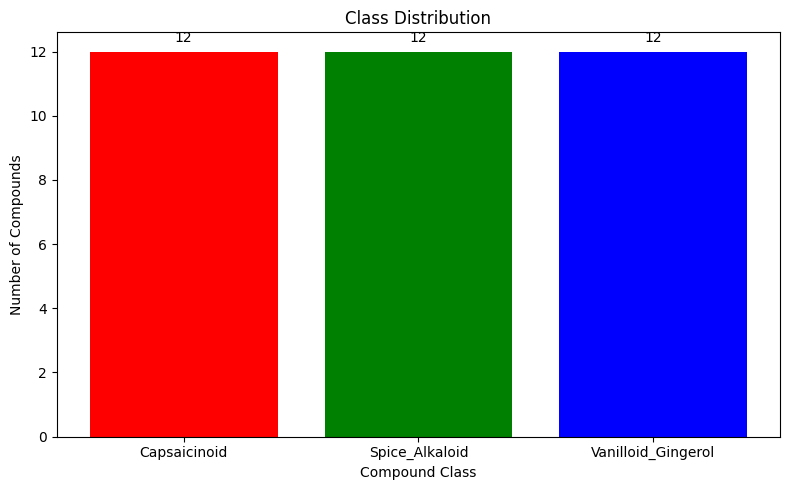

In [55]:
class_counts = molecule_df["class_name"].value_counts().sort_index()
colors = ["red", "green", "blue"]

plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.index, class_counts.values, color=colors)

for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(count), ha="center")

plt.xlabel("Compound Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()

## 2.4 EDA — Feature Correlation Heatmap (Top 20)

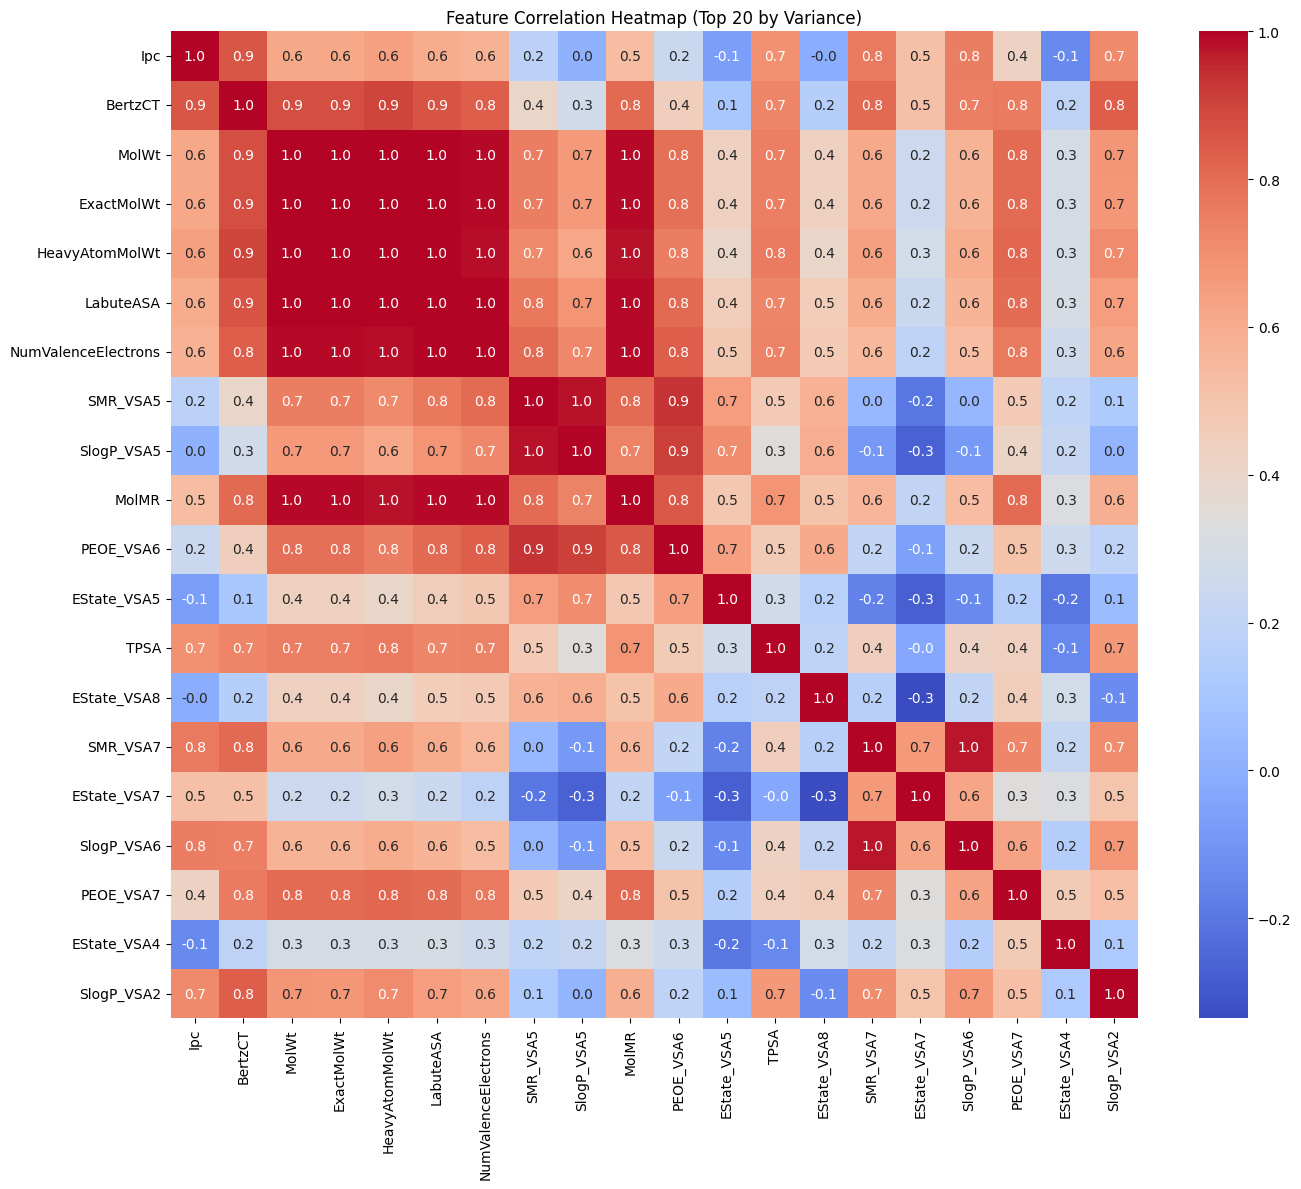

In [56]:
feature_cols = molecule_df.columns[3:]
feature_data = molecule_df[feature_cols]

top_20_features = feature_data.var().nlargest(20).index.tolist()
corr_matrix = feature_data[top_20_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap (Top 20 by Variance)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "correlation_heatmap.png"), bbox_inches="tight")
plt.show()

Most of the top 20 features are highly correlated, especially the molecular weight-related ones (MolWt, ExactMolWt, HeavyAtomMolWt), so they mostly carry the same information. A few features like TPSA and EState_VSA5 are more independent, meaning they capture different molecular properties. This redundancy is why PCA works well as it compresses correlated features into fewer components without losing much information.

## 2.5 EDA — Top 5 Feature Boxplots by Class

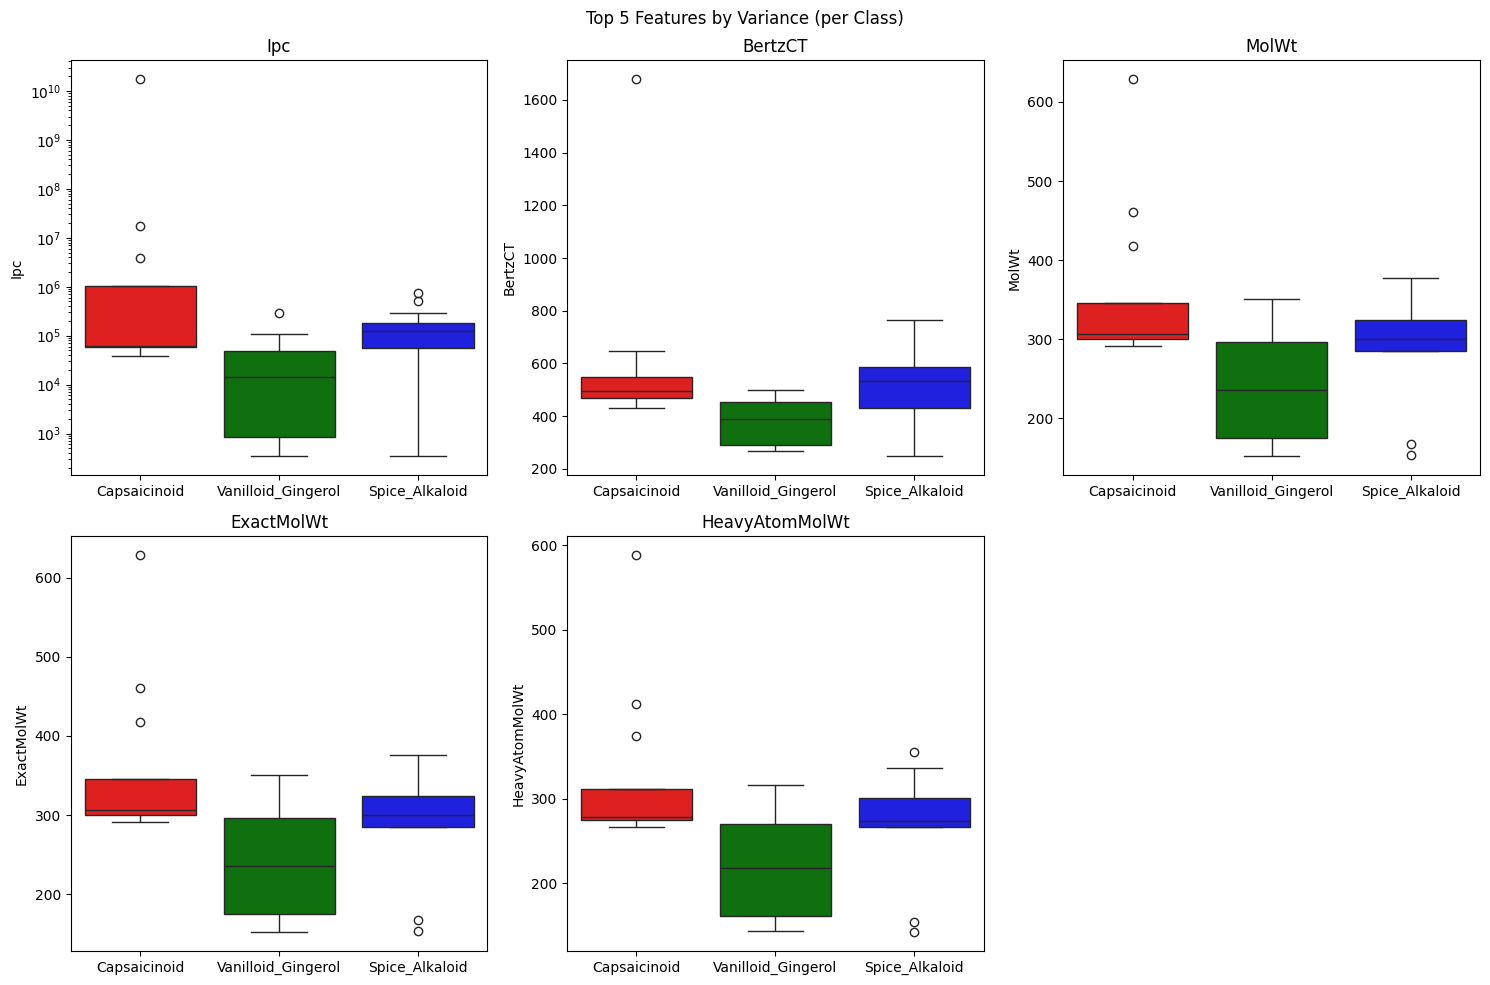

In [57]:
top_5_features = feature_data.var().nlargest(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, feat in enumerate(top_5_features):
    sns.boxplot(data=molecule_df, x="class_name", y=feat,
                hue="class_name", palette=colors, legend=False, ax=axes[idx])
    axes[idx].set_title(feat)
    axes[idx].set_xlabel("")
    if molecule_df[feat].max() / (molecule_df[feat].min() + 1) > 1000:
        axes[idx].set_yscale("log")

axes[-1].set_visible(False)
plt.suptitle("Top 5 Features by Variance (per Class)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "top5_boxplots.png"), bbox_inches="tight")
plt.show()

Only Ipc clearly separates the classes. Spice_Alkaloid has much higher values while the other two stay near zero (log scale applied due to extreme range). The remaining four features (BertzCT, MolWt, ExactMolWt, HeavyAtomMolWt) overlap heavily across all three classes, making them poor standalone discriminators. Also, MolWt, ExactMolWt, and HeavyAtomMolWt show nearly identical patterns, confirming the redundancy seen in the correlation heatmap.

## 2.6 Preprocessing — StandardScaler + Train/Test Split

In [58]:
feature_cols = molecule_df.columns[3:]
X = molecule_df[feature_cols].values
y = molecule_df["class_label"].values
compound_names = molecule_df["compound_name"].values

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X, y, compound_names, test_size=0.3, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"Features:  {X_train.shape[1]}")

# fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nPost-scaling train mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")

Train set: 25 samples
Test set:  11 samples
Features:  152

Post-scaling train mean: -0.0000, std: 0.9967


The 70/30 stratified split gives 25 train and 11 test samples, which is small but maintains equal class ratios. Post-scaling mean ≈ 0 and std ≈ 1 confirms StandardScaler is working correctly. Features are now centered and normalized, ready for PCA.

## 2.7 PCA Analysis

PCA is fit on the training set only to avoid data leakage, then used to determine how many components are needed to capture 95% of the total variance. Since many features are highly correlated (as shown in the heatmap), PCA can compress 152 features into far fewer components with minimal information loss.

In [59]:
# fit on train only (prevent data leakage)
pca = PCA()
pca.fit(X_train_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# index of first PC where cumulative variance >= 95%, +1 because argmax returns 0-based index
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")
print(f"PC1 explained variance: {explained_var[0]:.4f} ({explained_var[0]*100:.1f}%)")
print(f"PC2 explained variance: {explained_var[1]:.4f} ({explained_var[1]*100:.1f}%)")
print(f"PC3 explained variance: {explained_var[2]:.4f} ({explained_var[2]*100:.1f}%)")

Components needed for 95% variance: 10
PC1 explained variance: 0.3698 (37.0%)
PC2 explained variance: 0.1384 (13.8%)
PC3 explained variance: 0.1254 (12.5%)


## 2.8 Scree Plot (Explained Variance Ratio)

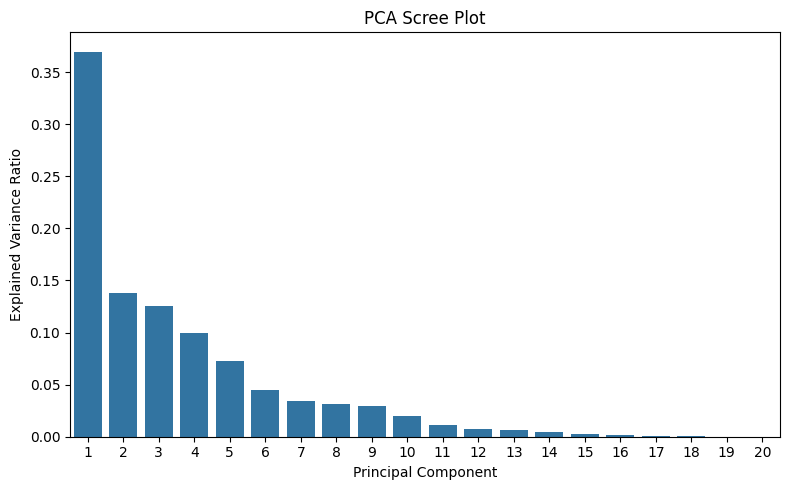

In [60]:
n_show = min(20, len(explained_var))

plt.figure(figsize=(8, 5))
sns.barplot(x=list(range(1, n_show + 1)), y=explained_var[:n_show])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "scree_plot.png"), bbox_inches="tight")
plt.show()

PC1 alone explains ~37% of the variance, and the first 5 components together cover over 70%, showing that most information in the 152 features can be captured by a handful of principal components. The rapid drop-off after PC5 confirms high redundancy among the original features, consistent with the correlation heatmap.